In [1]:
import pandas as pd
import numpy as np
from pandas import DataFrame

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path=r'C:\Users\aleci\Documents\Project 6 - Credit Card Fraud Detection\data\\'

## Part 1: Read in data

In [3]:
df=pd.read_csv(path+'creditcard.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.shape

(284807, 31)

In [17]:
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.shape

(284807, 31)

## Part 2: Check data quality

In [10]:
# check null values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [25]:
# add a column ID to the dataframe
df['ID']=1
df['ID']=df['ID'].cumsum()
df['ID'].describe()

count    284807.000000
mean     142404.000000
std       82216.843396
min           1.000000
25%       71202.500000
50%      142404.000000
75%      213605.500000
max      284807.000000
Name: ID, dtype: float64

In [26]:
df['random']=np.random.uniform(0, 1, len(df['ID']))
df['seg']=np.where(df['random'] <= 0.7, 'mod', 'val')

In [28]:
df.groupby('seg')['ID'].count()

seg
mod    199304
val     85503
Name: ID, dtype: int64

In [21]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
#from featurewiz import featurewiz
#from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
def model_evaluation():

    #Accuracy score
    print('Accuracy: %.3f' % accuracy_score(y_test, preds))

    #Precision score - model precision score represents the model’s ability to correctly predict the positives out of all the positive predictions it made
    print('Precision: %.3f' % precision_score(y_test, preds)) 

    #Recall score - model recall score represents the model’s ability to correctly predict the positives out of actual positives
    print('Recall: %.3f' % recall_score(y_test, preds))

    #Confusion matrix
    plot_confusion_matrix(model, X_test, y_test)       

    #ROC & AUC
    #Generate a baseline prediction (majority class)
    ns_probs = [0 for _ in range(len(y_test))]

    #Predict probabilities
    lr_probs = model.predict_proba(X_test)

    #Keep probabilities for the positive outcome only
    lr_probs = lr_probs[:, 1]

    #Calculate scores
    ns_auc = roc_auc_score(y_test, ns_probs)
    lr_auc = roc_auc_score(y_test, lr_probs)

    #Summarize scores
    print('Baseline: ROC AUC = %.3f' % (ns_auc))
    print(model_name+': ROC AUC = %.3f' % (lr_auc))

    #Calculate roc curves
    ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
    lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

    #Plot the roc curve for the model
    plt.figure()
    plt.plot(ns_fpr, ns_tpr, linestyle = '--', label = 'Baseline')
    plt.plot(lr_fpr, lr_tpr, marker = '.', label = model_name)

    #Axis labels
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

    #Predicted vs. actual graphs
    actuals_y = pd.DataFrame(data = actuals, columns = [target])
    probs_y = pd.DataFrame(data = probs, columns = ['score1', 'score2'])
    actuals_probs = pd.concat([actuals_y, probs_y], axis = 1)
    num_bins = 20
    binlabels = list(range(0, num_bins))
    actuals_probs['score_bin'] = pd.qcut(actuals_probs['score2'].rank(method = 'first'), num_bins, labels = binlabels)
    actuals_probs['score_bin'] = num_bins - actuals_probs['score_bin'].astype(int)
    df_grp = actuals_probs.groupby('score_bin')['score2'].mean()
    df_grp.plot()
    df_grp2 = actuals_probs.groupby('score_bin')[target].mean()
    df_grp2.plot()
    plt.legend(["Predicted", "Actual"])
    plt.xlabel('Score Bin')
    plt.title("Predicted vs. Actual")
    
    # save AUC ROC and use it as the weight in the ensemble method later
    return(lr_auc)

In [31]:
target='Class'

In [34]:
X=['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20','V21','V22','V23','V24','V25','V26','V27','V28','Amount']

In [35]:
# examine correlations 
df[df['seg']=='mod'][X].corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Time,1.000000,0.116726,-0.009619,-0.418286,-0.105323,0.171766,-0.062832,0.084344,-0.037284,-0.007492,...,-0.050203,0.045184,0.145096,0.053479,-0.017411,-0.232869,-0.040241,-0.006880,-0.008484,-0.010254
V1,0.116726,1.000000,-0.004483,0.004292,-0.000865,0.007719,-0.005311,-0.008995,0.001000,0.002350,...,-0.013730,-0.007362,0.004523,0.000340,0.000061,0.002042,-0.000353,-0.004722,0.008539,-0.233289
V2,-0.009619,-0.004483,1.000000,0.001040,-0.003440,0.013233,-0.009333,-0.016430,-0.002469,0.004974,...,-0.017767,-0.005726,0.001822,0.009619,0.001250,0.005986,-0.000675,0.000711,0.015429,-0.540601
V3,-0.418286,0.004292,0.001040,1.000000,-0.000126,0.006196,-0.000489,-0.003820,-0.001719,-0.000979,...,-0.004083,-0.006088,0.002422,-0.002441,0.000113,-0.002722,-0.001070,-0.004385,-0.001372,-0.214950
V4,-0.105323,-0.000865,-0.003440,-0.000126,1.000000,-0.005400,0.003539,0.004932,0.000388,0.002155,...,0.005782,0.007417,-0.001880,-0.003023,-0.001820,-0.001398,-0.001896,0.000205,-0.003950,0.106168
V5,0.171766,0.007719,0.013233,0.006196,-0.005400,1.000000,0.004669,0.000342,0.000514,-0.000118,...,0.008906,0.002990,0.002928,-0.000802,-0.000881,-0.002638,0.002143,-0.014527,-0.004782,-0.389055
V6,-0.062832,-0.005311,-0.009333,-0.000489,0.003539,0.004669,1.000000,-0.000544,-0.003947,0.001302,...,-0.007655,-0.004311,0.001421,0.001441,0.002761,0.000860,0.002656,0.007349,0.000596,0.215789
V7,0.084344,-0.008995,-0.016430,-0.003820,0.004932,0.000342,-0.000544,1.000000,0.002035,0.000006,...,-0.007948,-0.008512,0.000214,-0.004056,0.001327,0.000157,0.001420,0.009241,-0.004674,0.403079
V8,-0.037284,0.001000,-0.002469,-0.001719,0.000388,0.000514,-0.003947,0.002035,1.000000,0.000232,...,-0.005783,0.001716,-0.000642,-0.002494,0.002430,0.000489,-0.000922,0.003175,-0.001278,-0.102330
V9,-0.007492,0.002350,0.004974,-0.000979,0.002155,-0.000118,0.001302,0.000006,0.000232,1.000000,...,0.002369,0.000139,0.001521,0.000133,-0.001323,-0.002643,0.000215,0.000685,-0.006131,-0.045534


<AxesSubplot:>

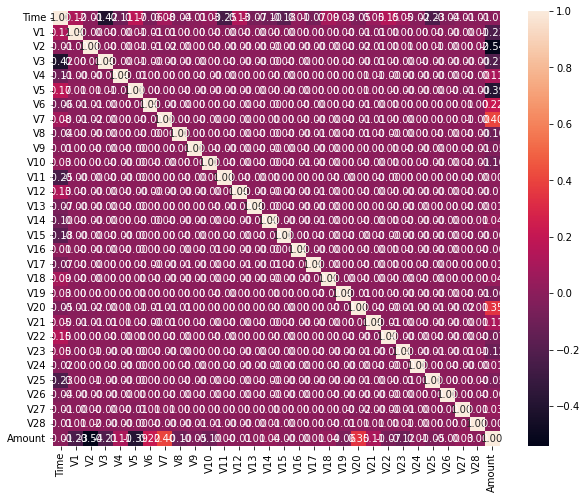

In [36]:
# visualize the correlation
fig=plt.figure(figsize=(10, 8))
sns.heatmap(df[df['seg']=='mod'][X].corr(), annot=True, fmt=".2f")

In [37]:
X_train=df[df['seg']=='mod'][X]
y_train=df[df['seg']=='mod'][target]

X_test=df[df['seg']=='val'][X]
y_test=df[df['seg']=='val'][target]

C:\Users\aleci\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.999
Precision: 0.765
Recall: 0.691
Baseline: ROC AUC = 0.500
Logistic Regression - Default: ROC AUC = 0.928


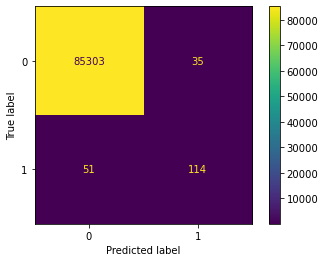

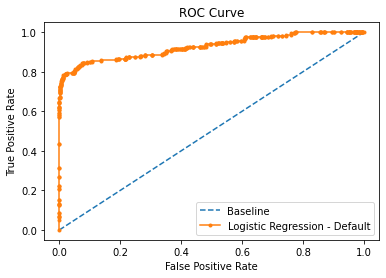

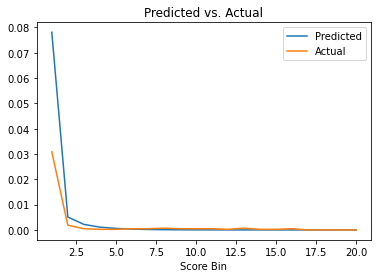

In [38]:
# 1) logistic regression
model=LogisticRegression()
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Logistic Regression - Default'

LR=model_evaluation()

Accuracy: 0.999
Precision: 0.907
Recall: 0.709
Baseline: ROC AUC = 0.500
Decision Tree - Default: ROC AUC = 0.933


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


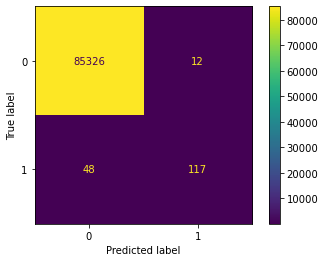

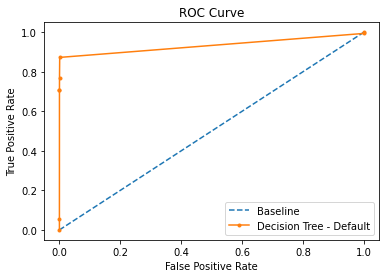

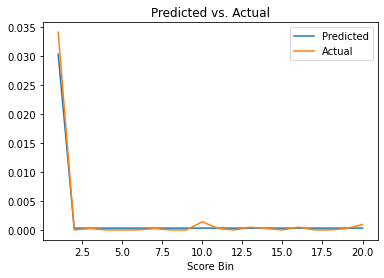

In [39]:
# 2) Decision Tree
model=DecisionTreeClassifier(max_depth=3, random_state=101, max_features=None, min_samples_leaf=3)
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Decision Tree - Default'

DT=model_evaluation()

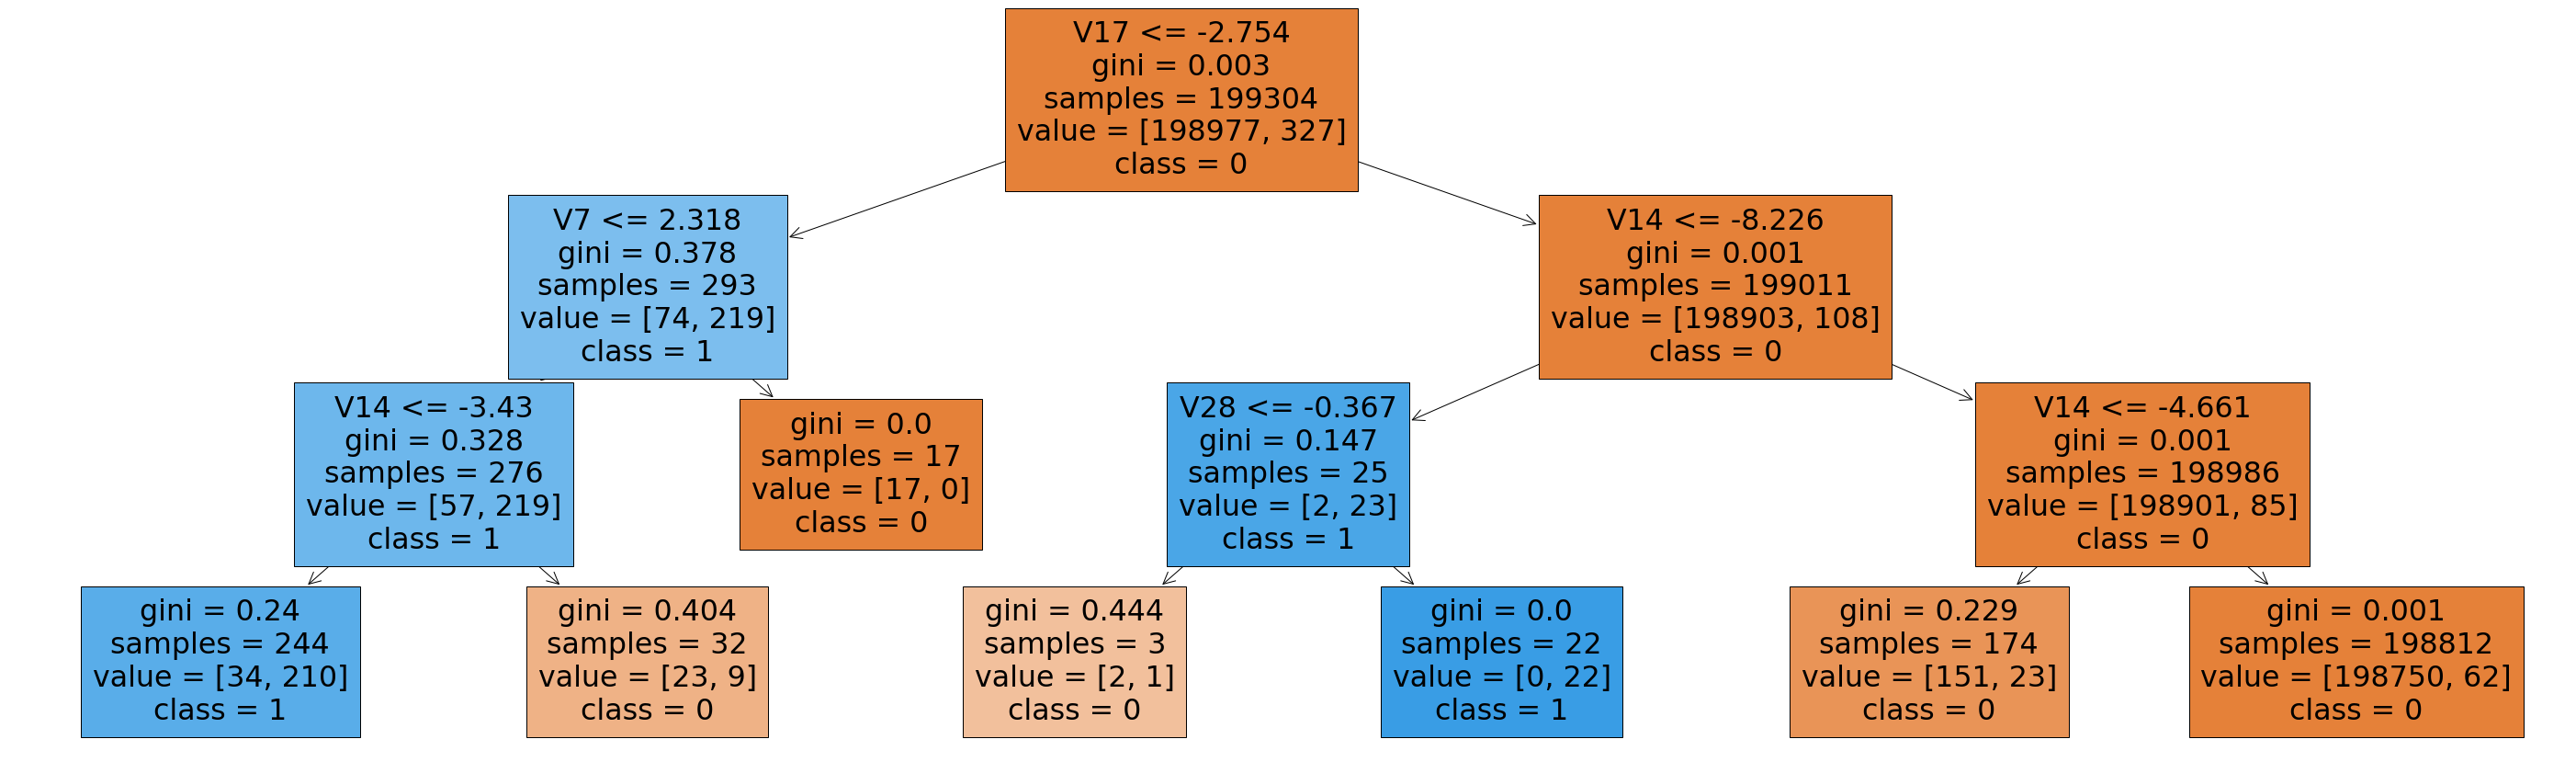

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model=DecisionTreeClassifier(max_depth=3, random_state=101, max_features=None, min_samples_leaf=3)
model=model.fit(X_train, y_train)

fig=plt.figure(figsize=(50, 15))
_ =tree.plot_tree(model, 
                  feature_names=X_train.columns, 
                  class_names=['0', '1'], filled=True)

Accuracy: 0.993
Precision: 0.173
Recall: 0.679


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Naive Bayes - Default: ROC AUC = 0.979


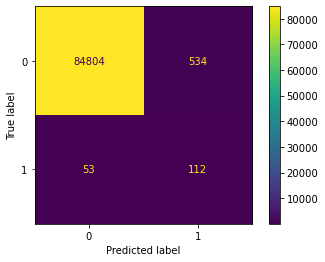

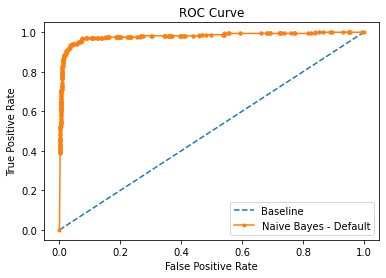

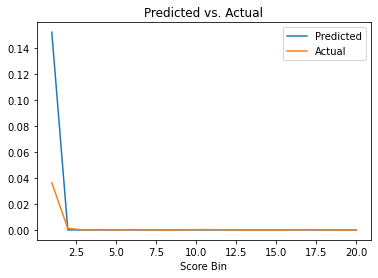

In [41]:
# 3) Naive Bayes
model=GaussianNB()
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Naive Bayes - Default'

NB=model_evaluation()

Accuracy: 0.998
Precision: 0.000
Recall: 0.000


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Stochastic Gradient Descent - Default: ROC AUC = 0.500


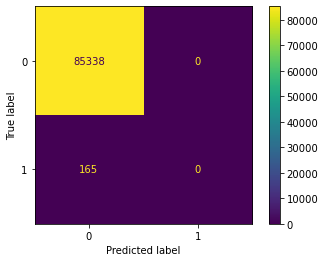

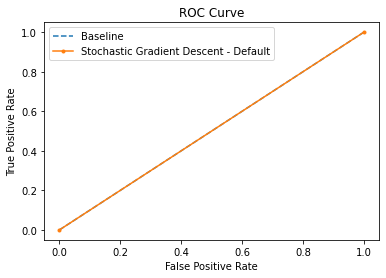

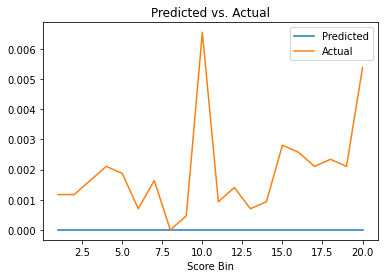

In [42]:
# 4) Stochastic Gradient Descent
model=SGDClassifier(loss='modified_huber', shuffle=True, random_state=101)
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Stochastic Gradient Descent - Default'

SGD=model_evaluation()

Accuracy: 0.998
Precision: 0.000
Recall: 0.000


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
KNN - Default: ROC AUC = 0.606


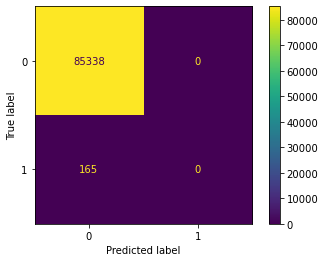

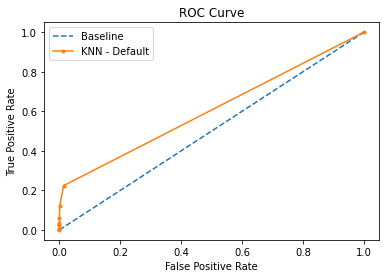

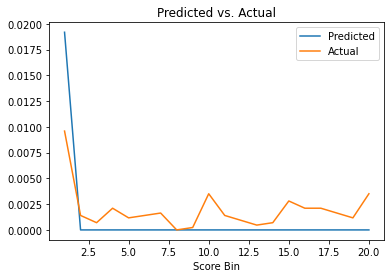

In [43]:
# 5) K Nearest Neighborhood (KNN)
model=KNeighborsClassifier(n_neighbors=17)
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='KNN - Default'

KNN=model_evaluation()

Accuracy: 0.999
Precision: 0.917
Recall: 0.606


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Light Gradient Boosting - Default: ROC AUC = 0.776


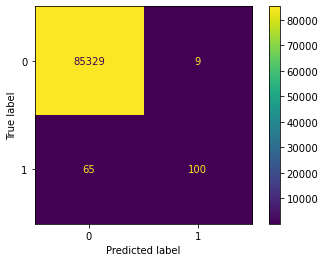

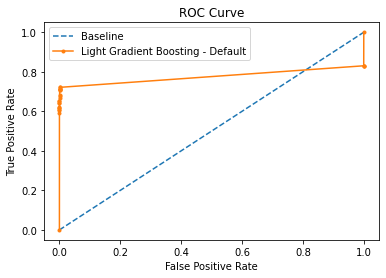

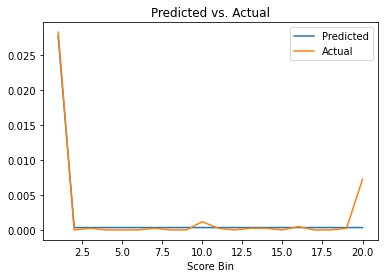

In [44]:
# 6) Light Gradint Boosting
model=GradientBoostingClassifier()
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Light Gradient Boosting - Default'

LGB=model_evaluation()

Accuracy: 1.000
Precision: 0.958
Recall: 0.824


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
XGBoost - Default: ROC AUC = 0.990


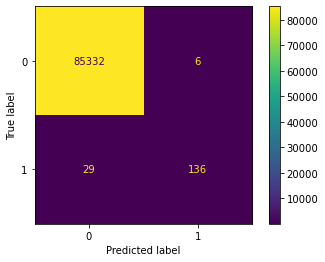

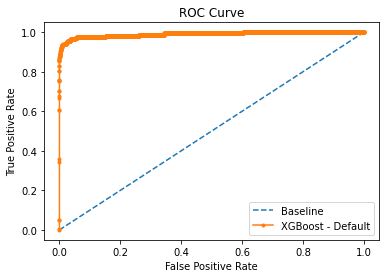

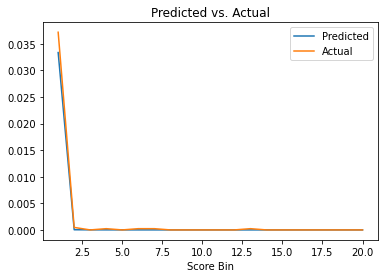

In [45]:
# 7) XGboost
model=XGBClassifier()
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='XGBoost - Default'

XGB=model_evaluation()

In [ ]:
# 8) SVM of SVC
# from sklearn.svm import SVC

# model=SVC(probability=True)
# modelname='SVM'

# model.fit(X_train, y_train)

# preds=model.predict(X_test)
# probs=model.predict_proba(X_test)
# actuals=y_test.reset_index(drop=True)
# model_name='SVM - Default'

# SVM=model_evaluation()

Accuracy: 1.000
Precision: 0.956
Recall: 0.794


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Random Forest - Default: ROC AUC = 0.965


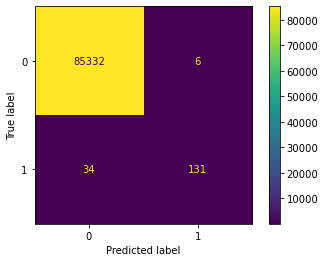

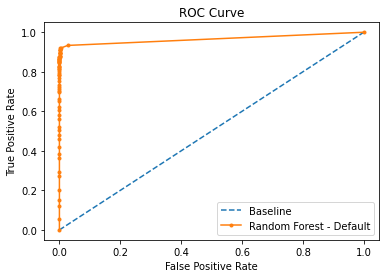

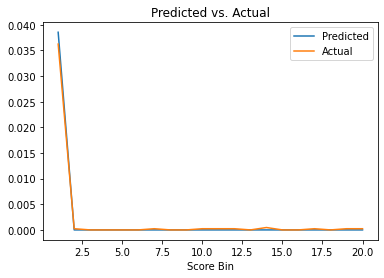

In [46]:
# 8) Random Forest
model=RandomForestClassifier()
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Random Forest - Default'

RF=model_evaluation()

In [47]:
def model_evaluation():

    #ROC & AUC
    #Generate a baseline prediction (majority class)
    ns_probs = [0 for _ in range(len(y_test))]

    #Predict probabilities
    lr_probs = model.predict_proba(X_test)

    #Keep probabilities for the positive outcome only
    lr_probs = lr_probs[:, 1]

    #Calculate scores
    ns_auc = roc_auc_score(y_test, ns_probs)
    lr_auc = roc_auc_score(y_test, lr_probs)

    #Summarize scores
    print('Baseline: ROC AUC = %.3f' % (ns_auc))
    print(model_name+': ROC AUC = %.3f' % (lr_auc))

    #Calculate roc curves
    ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
    lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

    #Plot the roc curve for the model
    plt.figure()
    plt.plot(ns_fpr, ns_tpr, linestyle = '--', label = 'Baseline')
    plt.plot(lr_fpr, lr_tpr, marker = '.', label = model_name)

    #Axis labels
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

    #Predicted vs. actual graphs
    actuals_y = pd.DataFrame(data = actuals, columns = [target])
    probs_y = pd.DataFrame(data = probs, columns = ['score1', 'score2'])
    actuals_probs = pd.concat([actuals_y, probs_y], axis = 1)
    num_bins = 20
    binlabels = list(range(0, num_bins))
    actuals_probs['score_bin'] = pd.qcut(actuals_probs['score2'].rank(method = 'first'), num_bins, labels = binlabels)
    actuals_probs['score_bin'] = num_bins - actuals_probs['score_bin'].astype(int)
    df_grp = actuals_probs.groupby('score_bin')['score2'].mean()
    df_grp.plot()
    df_grp2 = actuals_probs.groupby('score_bin')[target].mean()
    df_grp2.plot()
    plt.legend(["Predicted", "Actual"])
    plt.xlabel('Score Bin')
    plt.title("Predicted vs. Actual")
    
    # save AUC ROC and use it as the weight in the ensemble method later
    return(lr_auc)

C:\Users\aleci\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline: ROC AUC = 0.500
Ensemble Learning - Weighted Average: ROC AUC = 0.965


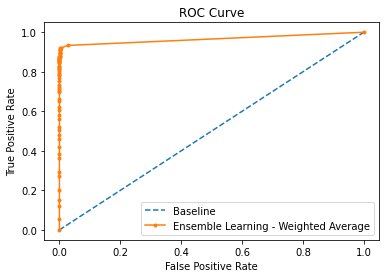

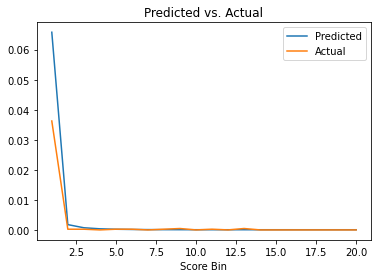

In [48]:
model_LR=LogisticRegression()
model_DT = DecisionTreeClassifier(max_depth = 3, random_state = 101, max_features = None, min_samples_leaf = 3)
model_NB=GaussianNB()
model_SGD=SGDClassifier(loss='modified_huber', shuffle=True, random_state=101)
model_KNN=KNeighborsClassifier(n_neighbors=15)
model_LGB = GradientBoostingClassifier()
model_XGB = XGBClassifier()
model_RF = RandomForestClassifier()

# train the model with the modeling sample
model_LR.fit(X_train, y_train)
model_DT.fit(X_train, y_train)
model_NB.fit(X_train, y_train)
model_SGD.fit(X_train, y_train)
model_KNN.fit(X_train, y_train)
model_LGB.fit(X_train, y_train)
model_XGB.fit(X_train, y_train)
model_RF.fit(X_train, y_train)

# score the validation sample 
Prob_LR = model_LR.predict_proba(X_test)
Prob_DT = model_DT.predict_proba(X_test)
Prob_NB = model_NB.predict_proba(X_test)
Prob_SGD = model_SGD.predict_proba(X_test)
Prob_KNN = model_KNN.predict_proba(X_test)
Prob_LGB = model_LGB.predict_proba(X_test)
Prob_XGB = model_XGB.predict_proba(X_test)
Prob_RF = model_RF.predict_proba(X_test)

# Use weight_exponent to reward the algorithms with higher ROC
weight_exponent = 2

w1 = LR**weight_exponent
w2 = DT**weight_exponent
w3 = NB**weight_exponent
w4 = SGD**weight_exponent
w5 = KNN**weight_exponent
w6 = LGB**weight_exponent
w7 = XGB**weight_exponent
w8 = RF**weight_exponent

# probs = (Prob_LR*w1 + Prob_DT*w2 + Prob_NB*w3 + Prob_KNN*w5 + Prob_LGB*w6 + Prob_XGB*w7 + Prob_RF*w8) / (w1+w2+w4+w5+w6+w7+w8)
probs = (Prob_LR*w1 + Prob_DT*w2 + Prob_NB*w3 + Prob_XGB*w7 + Prob_RF*w8) / (w1+w2+w3+w7+w8)
actuals = y_test.reset_index(drop=True)
model_name = "Ensemble Learning - Weighted Average"

EL_weighted_average = model_evaluation()